# Libraries

In [44]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sci
from sklearn.metrics import r2_score
import pickle

# Dataset upload and computing error model

### $x$ data

In [45]:
filename = r'/home/wmpjrufg/Documents/ic_andre_rimes/gen_dataset/z_dataset_2_wexp_menos_wfib2020ts.pkl'
with open(filename, 'rb') as f:
    dataset_x = pickle.load(f)

### $y$ data

In [46]:
data = pd.read_excel(r'/home/wmpjrufg/Documents/ic_andre_rimes/gen_dataset/data_models_rv2.xlsx', sheet_name='Modelos')
data.columns = data.columns.str.lower().str.replace(' ', '-')
data

,autor,output:-w_exp-(mm),fib-model-code-2020-(mm),wexp_menos_wfib2020,fib-model-code-2020--com-ts-variável-(mm),wexp_menos_wfib2020ts,norma-chinesa-(mm)
0,Viga S200-1.76-20 - Sokolov et al (2021),0.16,0.086159,0.073841,0.102130,0.057870,NaN
1,NaN,0.23,0.147127,0.082873,0.190783,0.039217,NaN
2,NaN,0.24,0.155568,0.084432,0.203058,0.036942,NaN
3,NaN,0.27,0.196838,0.073162,0.263069,0.006931,NaN
4,NaN,0.35,0.277502,0.072498,0.380363,-0.030363,NaN
...,...,...,...,...,...,...,...
336,NaN,0.19,0.217911,-0.027911,0.227492,-0.037492,NaN
337,NaN,0.22,0.247400,-0.027400,0.261534,-0.041534,NaN
338,Viga 23-6-11-2 - Clark (1956),0.17,0.150622,0.019378,0.150622,0.019378,NaN
339,Viga 23-6-11-3 - Clark (1956),0.19,0.108061,0.081939,0.108061,0.081939,NaN


### PySR model

In [47]:
filename = r'/home/wmpjrufg/Documents/ic_andre_rimes/test_model_error/fib2020ts/results_pysr_model_8020_fib2020ts-dataset2.pkl'
with open(filename, 'rb') as f:
    results_pysr_model_8020_dataset_1 = pickle.load(f)
    results_pysr_model_8020_dataset_1 = results_pysr_model_8020_dataset_1[1:]

results_pysr_model_8020_dataset_1

[{'diametro_da_armadura_mm': {'avg': 17.694558823529412,
   'std_dev': 6.0818843669065386},
  'resistencia_do_aco_fy_mpa': {'avg': 470.9779411764706,
   'std_dev': 101.18118336108488},
  'resistencia_a_tracao_do_concreto_mpa': {'avg': 3.110928812500933,
   'std_dev': 0.5053036284495501},
  'cobrimento_mm': {'avg': 32.89746323529412, 'std_dev': 10.713381638789606},
  'distancia_ao_centro_de_gravidade_da_armadura_mm': {'avg': 43.66948529411764,
   'std_dev': 12.273320648262958},
  'area_de_aco_tracionada_as_mm2': {'avg': 661.68125,
   'std_dev': 570.876681061085},
  'taxa_de_armadura_conforme_mc2020': {'avg': 0.02556552466306839,
   'std_dev': 0.015518902338295101},
  'tensao_na_armadura_menos_tension_stiffening_variavel_mpa': {'avg': 243.73652910202946,
   'std_dev': 118.93648834242825},
  'fib_model_code_2010': {'avg': 0.21425606623087654,
   'std_dev': 0.085089136943037},
  'eurocode_2': {'avg': 0.2219287422386836, 'std_dev': 0.07388105903448675},
  'nbr_6118_wk1_fissuracao_estabiliza

In [48]:
dataset_x[1].columns

Index(['diametro_da_armadura_mm', 'resistencia_do_aco_fy_mpa',
       'resistencia_a_tracao_do_concreto_mpa', 'cobrimento_mm',
       'distancia_ao_centro_de_gravidade_da_armadura_mm',
       'area_de_aco_tracionada_as_mm2', 'taxa_de_armadura_conforme_mc2020',
       'tensao_na_armadura_menos_tension_stiffening_variavel_mpa',
       'fib_model_code_2010', 'eurocode_2',
       'nbr_6118_wk1_fissuracao_estabilizada',
       'nbr_6118_wk2_fissuracao_nao_estabilizada', 'clark_1956',
       'desayiganesan_1985', 'oh_kang_1987', 'caldas_1997',
       'gergely_e_lutz_1968', 'equacao_15_do_artigo_de_belarbi_e_hsu_1994',
       'beta_conforme_fields_e_bischoff_2004', 'slip_de_yuan_et_al_2025',
       'slip_de_biscaia_e_soares_2020'],
      dtype='object')

### See best equation by R2 and Z-score parameters

In [49]:
df_models = {
                'r2 train': [],
                'r2 test': [],
                'rmse train': [],
                'rmse test': [],
                'score': [],
                'best equation': [],
            }
for idx, item in enumerate(results_pysr_model_8020_dataset_1):
    model = item["model"]
    df_models['r2 train'].append(model["train_r2"])
    df_models['r2 test'].append(model["test_r2"])
    df_models['rmse train'].append(model["train_rmse"])
    df_models['rmse test'].append(model["test_rmse"])
    df_models['score'].append(model["model_object"].get_best()['score'])
    df_models['best equation'].append(model["best_equation"])
df_models = pd.DataFrame(df_models)
df_models['gap rmse'] = abs(df_models['rmse train'] - df_models['rmse test'])
df_models['gap r2'] = abs(df_models['r2 train'] - df_models['r2 test'])
# df_models = df_models.sort_values(by='gap rmse')
# df_models = df_models.sort_values(by='gap r2')
df_models = df_models.sort_values(by='r2 train', ascending=False)
df_models.head()

,r2 train,r2 test,rmse train,rmse test,score,best equation,gap rmse,gap r2
55,0.749091,0.596424,0.043803,0.061642,0.073707,((resistencia_do_aco_fy_mpa + taxa_de_armadura...,0.017840,0.152667
39,0.748772,0.761362,0.044742,0.044338,0.054495,(-0.042470127 - (tensao_na_armadura_menos_tens...,0.000404,0.012590
78,0.725750,0.684049,0.047131,0.049359,0.094577,((abs(equacao_15_do_artigo_de_belarbi_e_hsu_19...,0.002227,0.041700
69,0.720974,0.699818,0.047909,0.046549,0.102449,(eurocode_2 + ((sin((resistencia_do_aco_fy_mpa...,0.001360,0.021157
74,0.718887,0.532786,0.047718,0.060023,0.216867,(sin(cube(4.963309 / resistencia_do_aco_fy_mpa...,0.012305,0.186102


In [50]:
equation = df_models.iloc[1]['best equation']
equation

'(-0.042470127 - (tensao_na_armadura_menos_tension_stiffening_variavel_mpa * 0.014420477)) * (eurocode_2 - (abs(slip_de_biscaia_e_soares_2020) + (area_de_aco_tracionada_as_mm2 - (cos(distancia_ao_centro_de_gravidade_da_armadura_mm - ((nbr_6118_wk1_fissuracao_estabilizada - sin(0.08256385 / (cobrimento_mm - distancia_ao_centro_de_gravidade_da_armadura_mm))) - oh_kang_1987)) / 0.64609706))))'

In [51]:
best_index = df_models['r2 train'].idxmax()
best_index = 39

In [52]:

def computing_equation(df, lista_colunas, lista_medias, lista_desvios):
    """
    Computes the PySR symbolic regression equation using z-score normalized inputs.
    """

    # --- Z-score normalization ---
    df_z = df.copy()
    for col, mi, sigma in zip(lista_colunas, lista_medias, lista_desvios):
        if sigma != 0:
            df_z[col] = (df[col] - mi) / sigma
        else:
            df_z[col] = 0.0

    # --- Variable mapping (normalized space) ---
    tensao_ts = df_z["tensao_na_armadura_menos_tension_stiffening_variavel_mpa"]
    eurocode2 = df_z["eurocode_2"]
    slip_bs20 = df_z["slip_de_biscaia_e_soares_2020"]
    as_mm2    = df_z["area_de_aco_tracionada_as_mm2"]
    d_cg_mm   = df_z["distancia_ao_centro_de_gravidade_da_armadura_mm"]
    nbr_6118  = df_z["nbr_6118_wk1_fissuracao_estabilizada"]
    cobr_mm   = df_z["cobrimento_mm"]
    oh_kang87 = df_z["oh_kang_1987"]

    # --- PySR symbolic equation ---
    resultado = (
        (-0.042470127 - (tensao_ts * 0.014420477))
        * (
            eurocode2
            - (
                np.abs(slip_bs20)
                + (
                    as_mm2
                    - np.cos(
                        d_cg_mm
                        - (
                            (nbr_6118 - np.sin(0.08256385 / (cobr_mm - d_cg_mm)) - oh_kang87)
                            / 0.64609706
                        )
                    )
                )
            )
        )
    )

    return resultado

In [53]:
mycolumns = [
    "tensao_na_armadura_menos_tension_stiffening_variavel_mpa",
    "eurocode_2",
    "slip_de_biscaia_e_soares_2020",
    "area_de_aco_tracionada_as_mm2",
    "distancia_ao_centro_de_gravidade_da_armadura_mm",
    "nbr_6118_wk1_fissuracao_estabilizada",
    "cobrimento_mm",
    "oh_kang_1987",
]
avg = []
std = []
for j in mycolumns:
    avg.append(results_pysr_model_8020_dataset_1[best_index][j]['avg'])
    std.append(results_pysr_model_8020_dataset_1[best_index][j]['std_dev'])

### Build whole dataset to compare

In [54]:
w = dataset_x[1].copy()
w['output:-w_exp-(mm)'] = data['output:-w_exp-(mm)']
w['fib'] = data['fib-model-code-2020--com-ts-variável-(mm)']
w['error'] = computing_equation(w, mycolumns , avg, std)
w['wnum'] = w['fib'] + w['error']
w['wnum/wexp'] = w['wnum'] / w['output:-w_exp-(mm)']

In [55]:
data = w.copy()
data.head()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,area_de_aco_tracionada_as_mm2,taxa_de_armadura_conforme_mc2020,tensao_na_armadura_menos_tension_stiffening_variavel_mpa,fib_model_code_2010,eurocode_2,...,gergely_e_lutz_1968,equacao_15_do_artigo_de_belarbi_e_hsu_1994,beta_conforme_fields_e_bischoff_2004,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,error,wnum,wnum/wexp
0,20.0,500,4.120341,25.0,39.0,628.0,0.0213,120.527746,0.125734,0.125292,...,0.241528,0.149956,0.116566,0.109686,0.082007,0.16,0.102130,0.065341,0.167471,1.046691
1,20.0,500,4.120341,25.0,39.0,628.0,0.0213,223.847983,0.176982,0.176359,...,0.317005,0.204348,0.197288,0.193326,0.156266,0.23,0.190783,0.043262,0.234045,1.017586
2,20.0,500,4.120341,25.0,39.0,628.0,0.0213,242.052198,0.184078,0.183430,...,0.327456,0.212052,0.208041,0.205301,0.167096,0.24,0.203058,0.037920,0.240977,1.004072
3,20.0,500,4.120341,25.0,39.0,628.0,0.0213,325.147190,0.218769,0.217999,...,0.378549,0.250139,0.259368,0.265222,0.221958,0.27,0.263069,-0.000554,0.262514,0.972275
4,20.0,500,4.120341,25.0,39.0,628.0,0.0213,447.784457,0.286574,0.285566,...,0.478411,0.311870,0.354810,0.388948,0.338382,0.35,0.380363,-0.006063,0.374300,1.069428


### Mean and standard deviation

In [56]:
data.describe()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,area_de_aco_tracionada_as_mm2,taxa_de_armadura_conforme_mc2020,tensao_na_armadura_menos_tension_stiffening_variavel_mpa,fib_model_code_2010,eurocode_2,...,gergely_e_lutz_1968,equacao_15_do_artigo_de_belarbi_e_hsu_1994,beta_conforme_fields_e_bischoff_2004,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,error,wnum,wnum/wexp
count,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,...,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000
mean,17.881056,468.002933,3.090431,32.846188,43.834604,680.651320,0.025807,244.690914,0.215334,0.222434,...,0.280588,0.274002,0.271735,0.276129,0.240335,0.261672,0.266323,0.014494,0.280817,1.109608
std,6.258067,102.262652,0.501076,10.776445,12.213950,585.507137,0.015466,119.278613,0.085003,0.074272,...,0.076230,0.091358,0.111409,0.129666,0.109379,0.115072,0.117894,0.070682,0.106491,0.205042
min,9.520000,276.000000,2.384602,12.800000,23.900000,78.500000,0.008263,0.000000,0.007169,0.048215,...,0.096138,0.089892,0.052197,0.070935,0.051614,0.140000,0.052197,-0.178155,0.115085,0.575423
25%,12.000000,392.000000,2.800000,25.000000,35.000000,315.000000,0.013739,167.236452,0.153106,0.166328,...,0.220388,0.209395,0.187933,0.191853,0.168592,0.190000,0.178993,-0.017161,0.217178,0.975690
50%,16.000000,500.000000,2.920876,30.000000,40.500000,452.000000,0.021300,224.523664,0.205254,0.214410,...,0.281083,0.260001,0.260513,0.255402,0.221958,0.230000,0.250469,0.022662,0.256182,1.096352
75%,20.000000,528.000000,3.269000,40.000000,49.100000,800.000000,0.031722,319.534072,0.260408,0.272964,...,0.329113,0.324399,0.338662,0.338895,0.296132,0.300000,0.330521,0.052594,0.307183,1.221559
max,35.800000,628.000000,5.308474,70.000000,94.500000,2826.000000,0.079968,628.000000,0.528081,0.437544,...,0.520959,0.573472,0.656073,0.913442,0.676814,0.790000,0.701453,0.255772,0.769015,1.874937


### $R^2$

In [57]:
obs = data['output:-w_exp-(mm)']
pred = data['wnum']
r2_fib_model_2020 = r2_score(obs, pred)
r2_fib_model_2020

0.7856227286981906

# Charts

In [58]:
name = 'fib_model_2020t-com-ts-variável-pysr-model-dataset-2-8020'

### Predict versus Experimental

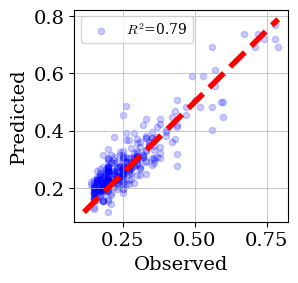

In [59]:
dpi = 600               # Change as you wish
b_cm = 7                       # Change as you wish
h_cm = 7                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm
label_x = 'Observed'            # Change as you wish
label_y = 'Predicted'           # Change as you wish
size_label = 14                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 14                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish
size_line = 4           # Change as you wish
style_line = '--'       # Change as you wish
color_line = 'red'      # or hexadecimal. Change as you wish
labels_legend = [rf'$R^2$={r2_fib_model_2020:.2f}']   # Change as you wish
size_legend = 10                # Change as you wish
location_legend = 'upper left'  # Change as you wish - 'best' look up by the best fit
fig, ax = plt.subplots(figsize=(b_input, h_input))
lims = [
            min(data['output:-w_exp-(mm)'].min(), data['wnum'].min()),
            max(data['output:-w_exp-(mm)'].max(), data['wnum'].max())
        ]

# Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

# Plot data y = x and scatter
ax.plot(lims, lims, linewidth=size_line, linestyle=style_line, color=color_line,)
ax.scatter(data["output:-w_exp-(mm)"], data["wnum"], alpha=0.2, color='blue', s=20, label=labels_legend[0])
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_scatter-line_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

### KDE numerical model - original model

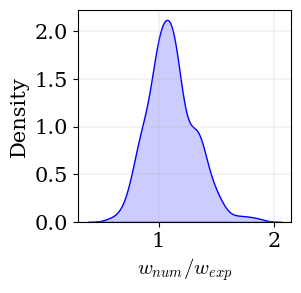

In [60]:
dpi = 600               

b_cm = 7            
h_cm = 7
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

label_y = 'Density'
label_x = '$w_{num}/w_{exp}$'   
size_label = 15
color_label = 'black'
size_axis = 15
color_axis = 'black'           

labels_legend = ['fib Model 2020']   
size_legend = 9                
location_legend = 'upper right'  

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=data, x='wnum/wexp', fill=True, alpha=0.2, color='blue', ax=ax, label=labels_legend[0])
# ax.legend(fontsize=size_legend, loc=location_legend)
fig.savefig(f'z_kde_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Goodness-of-fit

### Anderson-Darling test

Normal

In [61]:
# alpha = 5
# res = sci.stats.anderson(np.log(data['wnum/wexp']), dist="norm")
# stat = res.statistic
# crit = res.critical_values[res.significance_level == alpha][0]
# decision = "Accepted" if stat < crit else "Rejected"
# print(f"AD Statistic: {stat:.4f}")
# print(f"Critical Value at {alpha}% significance level: {crit:.4f}")
# print(f"Null Hypothesis: {decision}")

### Kolmogorov-Smirnov test

t-student

In [62]:
x = data['wnum/wexp'].values
df, loc, scale = sci.stats.t.fit(x)
print(f"\nFitted Student-t parameters:\nDegrees of freedom: {df:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 't', args=(df, loc, scale))
print("\nKolmogorov-Smirnov Test for Student-t Distribution:")
print(f"Student-t KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Student-t parameters:
Degrees of freedom: 11.6888, Location: 1.1026, Scale: 0.1865

Kolmogorov-Smirnov Test for Student-t Distribution:
Student-t KS statistic: 0.0568
p-value: 0.2134


Normal

In [63]:
x = data['wnum/wexp'].values
loc, scale = sci.stats.norm.fit(x)
print(f"\nFitted Normal parameters:\nLocation: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'norm', args=(loc, scale))
print("\nKolmogorov-Smirnov Test for Normal Distribution:")
print(f"Normal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Normal parameters:
Location: 1.1096, Scale: 0.2047

Kolmogorov-Smirnov Test for Normal Distribution:
Normal KS statistic: 0.0755
p-value: 0.0390


Log-normal

In [64]:
x = data['wnum/wexp'].values
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.1605, Location: -0.1545, Scale: 1.2479

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0441
p-value: 0.5065


### Genetate statistics for Lognormal

In [65]:
mu = np.log(scale)
sigma = shape

mean = loc + np.exp(mu + 0.5*sigma**2)
var = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std = np.sqrt(var)

print("\nLognormal Distribution Moments after fitting:")
print(f"Mean = {mean:.3f}")
print(f"Std  = {std:.3f}")


Lognormal Distribution Moments after fitting:
Mean = 1.110
Std  = 0.204


#### Generate synthetic data

In [66]:
sigma = np.sqrt(np.log(1 + (std / mean)**2))
mu = np.log(mean) - 0.5 * sigma**2

shape = sigma
loc = 0.0
scale = np.exp(mu)

print(f"shape = {shape:.4f}")
print(f"loc   = {loc:.4f}")
print(f"scale = {scale:.4f}")

n_samples = 20000
synthetic_data = sci.stats.lognorm.rvs(s=shape, loc=loc, scale=scale, size=n_samples)

shape = 0.1825
loc   = 0.0000
scale = 1.0913


In [67]:
# Double check the fit on the synthetic data
x = synthetic_data.copy()
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.1830, Location: -0.0025, Scale: 1.0927

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0047
p-value: 0.7616


#### Synthetic data versus original data

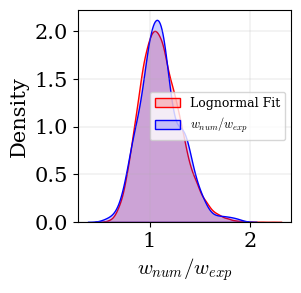

In [68]:
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=synthetic_data, fill=True, alpha=0.2, color='red', label='Lognormal Fit', ax=ax)
sns.kdeplot(data=list(data['wnum/wexp']), fill=True, alpha=0.2, color='blue', label='$w_{num}/w_{exp}$', ax=ax)
ax.legend(fontsize=size_legend, loc='center right')
fig.savefig(f'z_kde_{name}_gt_versus_lognormal.png', dpi=dpi, bbox_inches='tight')
plt.show()